# 5. Inclination estimation and Fourier-domain compression

## Estimating the inclination

The star's inclination is usually unknown, and getting it wrong warps the
recovered map. jittermap estimates it by refitting the surface at each
trial inclination and scoring the fit — the *profile objective*
$J(\beta)$. Scanning $J(\beta)$ also shows *how much* each data type
knows about the tilt:

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


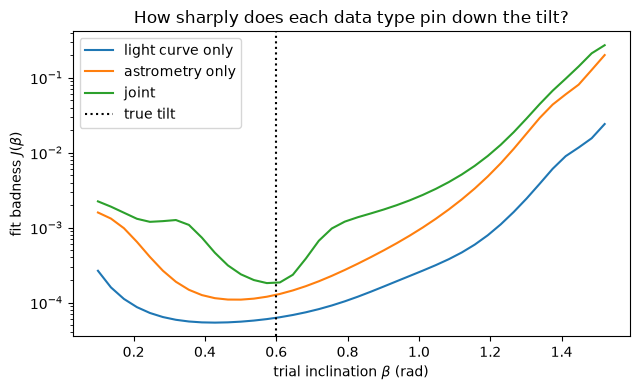

In [2]:
from jittermap.inference.inclination import profile_objective

L, N = 10, 100
INC_TRUE = 0.6
times = np.linspace(0, 2*np.pi, N, endpoint=False)
star = jm.multispot_surface([(30, 315, 18.0), (-15, 30, 13.0)], L,
                            texture_amplitude=0.002, texture_seed=3)
fm = jm.ForwardModel(times, l_max=L)
data = fm.observe(star, inclination=INC_TRUE, channels="xyp", stacked=False)

betas = np.linspace(0.1, np.pi/2 - 0.05, 40)
plt.figure(figsize=(6.5, 4))
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    y_vec = np.concatenate([data[c] for c in ch])
    J = [profile_objective(b, y_vec, ch, L, fm.kernels, fm._precomp, lam=2e-4)
         for b in betas]
    plt.semilogy(betas, J, label=label)
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("fit badness $J(\\beta)$")
plt.title("How sharply does each data type pin down the tilt?")
plt.legend(); plt.tight_layout()

The light-curve objective is nearly flat — a wide range of tilts fit the
photometry almost equally well *even with noiseless data*. This is the
inclination ambiguity of light curves. Adding astrometry carves a sharp
minimum at the truth:

In [3]:
for ch, label in [("p", "light curve"), ("xy", "astrometry"), ("xyp", "joint")]:
    res = jm.reconstruct({c: data[c] for c in ch}, times, L, channels=ch,
                         lam=2e-4, model=fm)
    print(f"{label:11s}: estimated tilt {res.inclination:.3f} rad "
          f"(true {INC_TRUE})")

light curve: estimated tilt 0.426 rad (true 0.6)


astrometry : estimated tilt 0.484 rad (true 0.6)


joint      : estimated tilt 0.588 rad (true 0.6)


## The signal is a frequency comb

One practical bonus of the model: for uniform sampling over a rotation,
the signals contain only the harmonics $m\omega$ of the rotation rate,
$m = -L..L$. So $N$ time samples compress **losslessly** into just $2L+1$
Fourier coefficients — handy for storing and fitting long campaigns:

compressed data still fits the model exactly: True
100 time samples -> 21 numbers, nothing lost


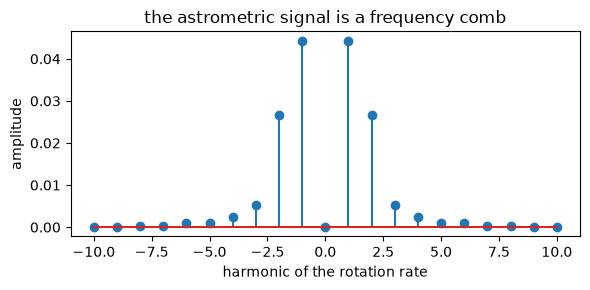

In [4]:
from jittermap.forward.fourier import compress, fourier_design_matrix
from jittermap.forward.kernels import compute_A_lm

A_x, _ = compute_A_lm(L)
y_x = fm.observe(star, INC_TRUE, channels="x")
f = compress(y_x, L)
F = fourier_design_matrix(L, INC_TRUE, A_x)
print("compressed data still fits the model exactly:",
      np.allclose(f, F @ star, atol=1e-12))
print(f"{N} time samples -> {2*L+1} numbers, nothing lost")

m_vals = np.arange(-L, L+1)
plt.figure(figsize=(6, 3))
plt.stem(m_vals, np.abs(f))
plt.xlabel("harmonic of the rotation rate")
plt.ylabel("amplitude")
plt.title("the astrometric signal is a frequency comb")
plt.tight_layout()